<a href="https://colab.research.google.com/github/muskan2109/FML_Practicals/blob/main/TASK4_EE510.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

**Load dataset**

In [ ]:
data = pd.read_csv("/content/wireless_signal_quality_dataset.xlsx - Sheet1.csv")

print("First five Records")
print(data.head())

print("\nDateset Shape:")
print(data.shape)

First five Records
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2         

**Step2: Separate Feature and Target**

In [ ]:


x = data.drop("Quality",axis=1)
y =data["Quality"]

*Step 3 Encode Target Labels

In [ ]:
y = data["Quality"]
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nClasses:")
print(encoder.classes_)


Classes:
['Excellent' 'Fair' 'Good' 'Poor']


**Step 4: Split Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

**Step5: Build Random forest Model**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    random_state=42,
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

**Step6: Prediction**

In [ ]:
y_pred = dt.predict(X_test)


**Step7: Accuracy**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy : {:.2f}%".format(accuracy * 100))


Accuracy : 96.00%


**Step8: Classsification Report**

In [ ]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in encoder.classes_]
    ))


Classification Report:
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00         1
        Fair       1.00      0.89      0.94         9
        Good       0.67      1.00      0.80         2
        Poor       1.00      1.00      1.00        13

    accuracy                           0.96        25
   macro avg       0.92      0.97      0.94        25
weighted avg       0.97      0.96      0.96        25



**Step9: Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 1  0  0  0]
 [ 0  8  1  0]
 [ 0  0  2  0]
 [ 0  0  0 13]]


**Step10: Features Importance**

In [ ]:
importance = pd.Series(
    dt.feature_importances_,
    index=x.columns
)

importance = importance.sort_values(ascending=False)

print("\nFeatures Importance:")
print(importance)


Features Importance:
Signal_Strength_dBm          0.461327
SNR_dB                       0.350824
Estimated_Throughput_Mbps    0.112353
Interference_dB              0.075496
Distance_m                   0.000000
Frequency_GHz                0.000000
Channel_Bandwidth_MHz        0.000000
Noise_Floor_dBm              0.000000
Connected_Devices            0.000000
dtype: float64


**Step11: Plot Feature Importance**

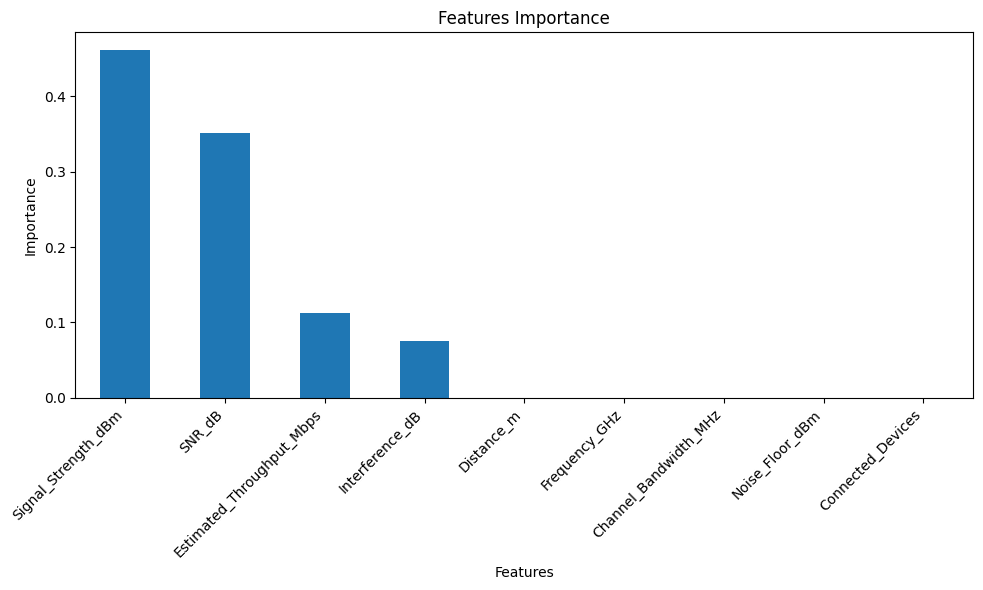

In [ ]:
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Features Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()